In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
n_dot = np.load("MGA-E-05032025_300ml-min_Analytik_MS_composition.npy")
timestamps = np.load("MGA-E-05032025_300ml-min_Analytik_MS_times.npy")

The switching times are ordered in reverse (ie. the index i) is the time at which the i-th-to last switch happened.

In [3]:
switching_periods = np.array(
    [
        45.35,
        45.18,
        45.06,
        44.98,
        45.20,
        45.16,
        45.11,
        45.03,
        45.10,
        45.15,
    ]
)
switching_times = np.flip(np.cumsum(-switching_periods))
switching_times = np.append(switching_times, 0)
print(switching_times)

[-451.32 -406.17 -361.07 -316.04 -270.93 -225.77 -180.57 -135.59  -90.53
  -45.35    0.  ]


In [4]:
intervals = [
    (switching_times[i], switching_times[i + 1])
    for i in range(len(switching_times) - 1)
]
intervals

[(-451.31999999999994, -406.16999999999996),
 (-406.16999999999996, -361.06999999999994),
 (-361.06999999999994, -316.03999999999996),
 (-316.03999999999996, -270.92999999999995),
 (-270.92999999999995, -225.76999999999998),
 (-225.76999999999998, -180.57),
 (-180.57, -135.59),
 (-135.59, -90.53),
 (-90.53, -45.35),
 (-45.35, 0.0)]

In [5]:
timestamps = timestamps - timestamps[-1]
time_delta = timestamps.astype("float") * 1e-9

np.savez("MGA-E-05032025_300ml-min_Analytik_MS.npz", n_dot=n_dot, time_delta=time_delta)


t_range = (time_delta.min(), time_delta.max())

In [6]:
import scipy
import scipy.interpolate

interp_H2 = scipy.interpolate.interp1d(time_delta, n_dot[0], kind="linear")
interp_Ar = scipy.interpolate.interp1d(time_delta, n_dot[1], kind="linear")

interp_H2(-90)

array(1.31095481e-06)

In [7]:
interp = scipy.interpolate.interp1d(
    time_delta,
    n_dot,
    kind="linear",
    fill_value="extrapolate",
)

In [8]:
t = np.linspace(*t_range, 1000)
n_dot_interp = interp(t)

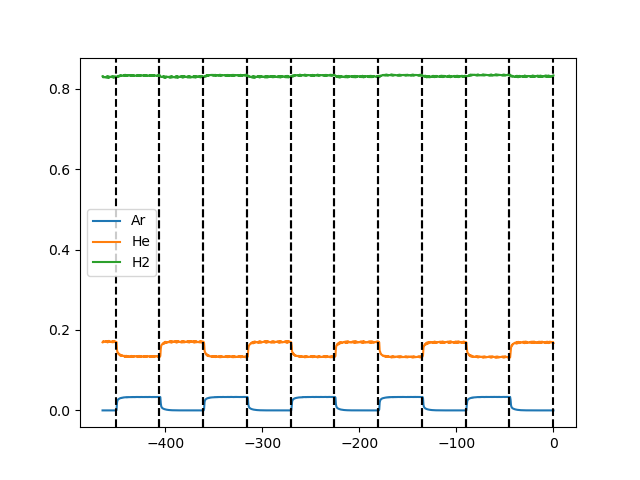

In [9]:
plt.plot(t, n_dot_interp[0], label="Ar")
plt.plot(t, n_dot_interp[1], label="He")
plt.plot(t, n_dot_interp[2], label="H2")
for interval in intervals:
    plt.axvline(interval[0], color="black", linestyle="--")
    plt.axvline(interval[1], color="black", linestyle="--")
plt.legend()

(10, 3, 180)


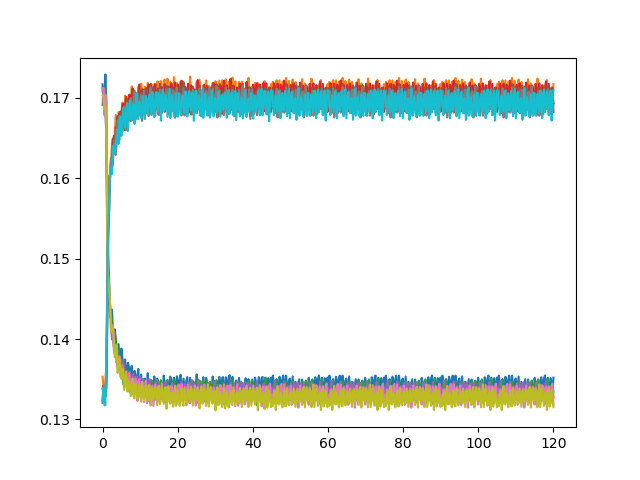

In [11]:
n_dots = []

for interval in intervals:

    t_original = np.linspace(interval[0], interval[0] + 45, 4 * 45)
    n_dot_interp_original = interp(t_original)  # 45 seconds at 4/s resolution
    t_auxilliary = np.linspace(interval[0] + 30, interval[0] + 45, 4 * 15)
    n_dot_auxilliary = interp(t_auxilliary)  # 15 seconds at 4/s resolution
    n_dot_auxilliary = np.tile(n_dot_auxilliary, (1, 5))
    n_dot_interp = np.concatenate([n_dot_interp_original, n_dot_auxilliary], axis=1)
    n_dots.append(n_dot_interp_original)
    t = np.linspace(interval[0], interval[0] + 120, 4 * 120)

    plt.plot(t - interval[0], n_dot_interp[1], label=interval)
# plt.legend()
n_dots = np.array(n_dots)
print(n_dots.shape)